# AI/ML Project - Smart School ECAM

This notebook is divided into two main parts:

1. Failure prediction: prediction of students' exam grades.
2. Automatic correction: OCR-based recognition of handwritten characters or digits.

# Part A - Failure Prediction

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
sns.set_theme(style="whitegrid")

## Chargement du dataset

#### Dataset Overview

In [3]:
df = pd.read_csv("../data/student_failure/train.csv")
df.head()

,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


#### Dataset Shape

In [4]:
df.shape

(630000, 15)

#### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

#### Column Names

In [6]:
df.columns

Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')

### Dataset Description



Le dataset contient environ 630 000 observations et 15 variables. Il s’agit d’un dataset relativement volumineux, ce qui est avantageux pour l’entraînement de modèles de Machine Learning, car cela permet d’avoir un grand nombre d’exemples et de limiter le risque d’overfitting.

La variable cible est `score_examen`, qui représente la note finale obtenue par l’étudiant. Étant donné que cette variable est continue et numérique, le problème est formulé comme un problème de régression.

Le dataset contient à la fois des variables numériques et catégorielles :
- Variables numériques : âge, heures d’étude, assiduité, heures de sommeil, etc.
- Variables catégorielles : genre, niveau d’étude, accès à internet, méthode d’étude, difficulté de l’examen, etc.

Une première analyse montre la présence de valeurs manquantes dans certaines colonnes, notamment `heures_etude`, `acces_internet` et `methode_etude`. Ces valeurs devront être traitées lors de la phase de preprocessing.

Enfin, la diversité des variables suggère que plusieurs facteurs peuvent influencer la performance des étudiants, ce qui rend ce problème particulièrement intéressant pour une analyse prédictive.

Cependant, certaines variables peuvent être déclaratives (par exemple les heures d’étude), ce qui peut introduire un biais ou des incohérences dans les données et affecter les prédictions du modèle.

## Exploratory Data Analysis (EDA)

### Distribution of the Target Variable

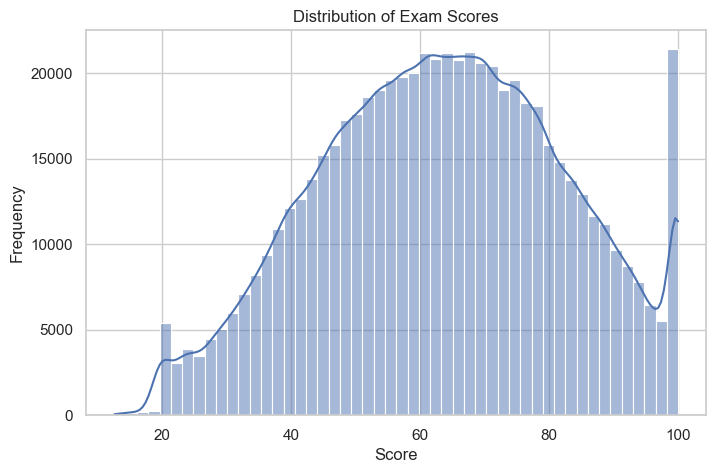

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["score_examen"], bins=50, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.savefig("score_distribution.png") 
plt.show()

#### Analysis



La distribution de la variable cible `score_examen` montre une répartition globalement en forme de cloche, ce qui suggère une distribution proche d’une loi normale.

La majorité des étudiants obtiennent des scores autour de 60 à 70, ce qui indique un niveau moyen global.

On observe également une concentration de valeurs proches de 100, ce qui peut s’expliquer par un effet de plafond (score maximal atteint).

Cette distribution confirme que la variable cible est continue et adaptée à un problème de régression.

La présence d’un pic près de 100 pourrait indiquer soit des étudiants très performants, soit une limite dans le système de notation.

### Correlation Analysis

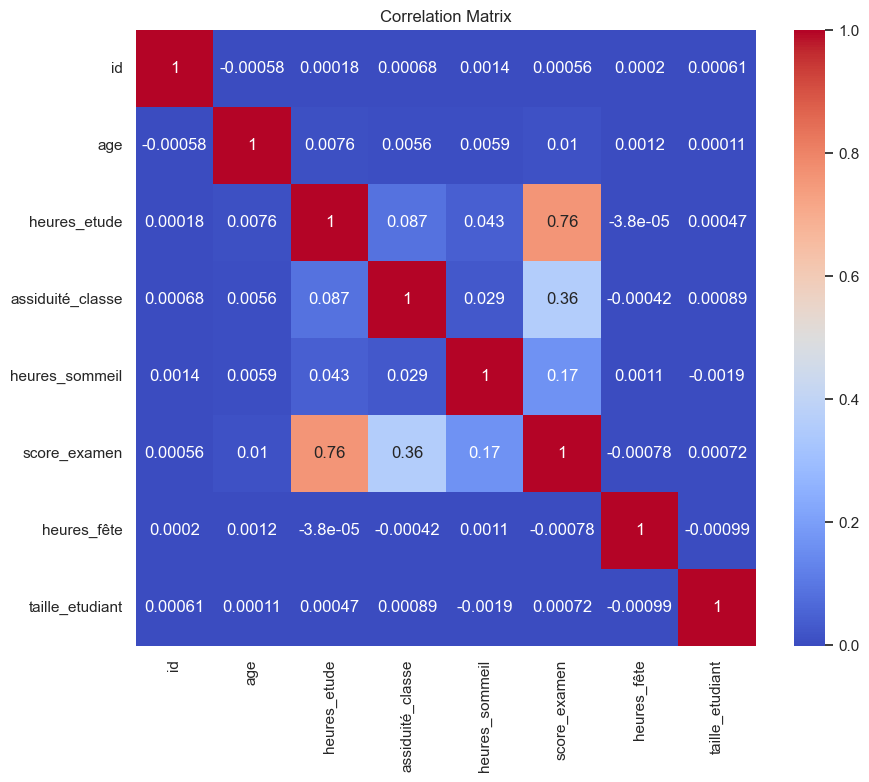

In [8]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

#### Analysis

La matrice de corrélation met en évidence les relations entre les variables numériques et le score d’examen.

On observe une forte corrélation positive entre `heures_etude` et `score_examen` (≈ 0.76), ce qui indique que le temps consacré aux études est un facteur déterminant de la performance.

L’assiduité en classe présente également une corrélation positive modérée (≈ 0.36), ce qui suggère que la présence en cours contribue à améliorer les résultats.

Le nombre d’heures de sommeil montre une corrélation plus faible (≈ 0.17), indiquant un impact limité mais non négligeable.

En revanche, certaines variables comme l’âge, les heures de fête, la taille ou l’identifiant (`id`) n’ont pratiquement aucune corrélation avec le score d’examen. Ces variables pourraient être peu pertinentes pour la prédiction.

Enfin, la forte corrélation entre certaines variables et la cible confirme que le modèle de régression pourra exploiter ces relations linéaires.

### Relationship Between Key Features

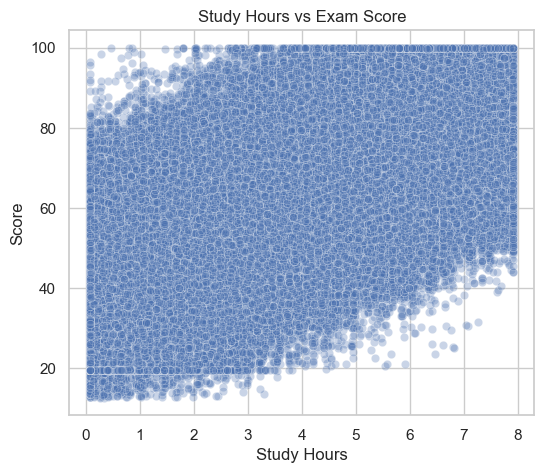

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["heures_etude"], y=df["score_examen"], alpha=0.3)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.savefig("study_hours_vs_score.png")
plt.show()

#### Analysis

Ce graphique met en évidence la relation entre le nombre d’heures d’étude et le score d’examen.

On observe une tendance positive : les étudiants qui consacrent davantage de temps à l’étude ont généralement de meilleurs résultats. Cela confirme la forte corrélation observée précédemment dans la matrice de corrélation.

Cependant, la dispersion des points montre que cette relation n’est pas parfaitement linéaire. Pour un même nombre d’heures d’étude, les scores peuvent varier de manière significative, ce qui indique que d’autres facteurs influencent également la performance.

On observe également un effet de plafond avec une concentration de valeurs proches de 100, ce qui suggère que certains étudiants atteignent le score maximal.

Cela montre que le temps d’étude est un facteur important mais non suffisant pour expliquer entièrement la performance académique.

### Attendance vs Exam Score

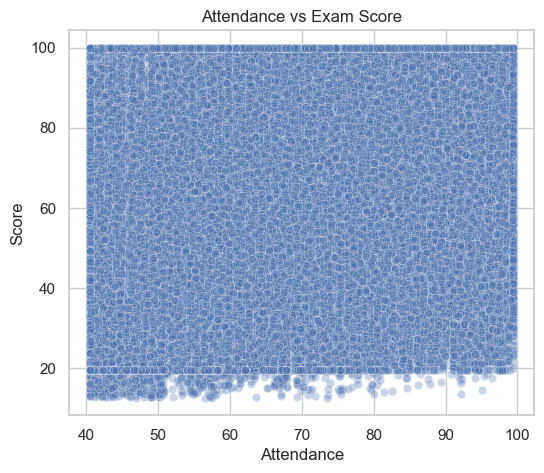

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["assiduité_classe"], y=df["score_examen"], alpha=0.3)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Score")
plt.savefig("attendance_vs_score.png")
plt.show()

#### Analysis

Ce graphique illustre la relation entre l’assiduité en classe et le score d’examen.

On observe une tendance globalement positive : les étudiants plus assidus ont tendance à obtenir de meilleurs résultats. Cela est cohérent avec la corrélation modérée observée précédemment.

Cependant, la dispersion importante des points indique que cette relation est moins forte que celle observée avec les heures d’étude. Pour un même niveau d’assiduité, les scores peuvent varier fortement.

De plus, certains étudiants ayant une forte assiduité obtiennent malgré tout des résultats faibles, ce qui suggère que la présence en classe ne garantit pas nécessairement une bonne compréhension.

Ainsi, l’assiduité apparaît comme un facteur important, mais insuffisant à elle seule pour expliquer la performance académique.

### Sleep Hours vs Exam Score

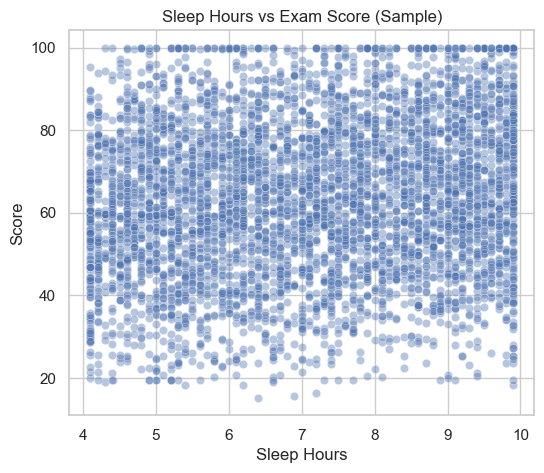

In [11]:
df_sample = df.sample(5000, random_state=42)

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_sample["heures_sommeil"],
    y=df_sample["score_examen"],
    alpha=0.4
)

plt.title("Sleep Hours vs Exam Score (Sample)")
plt.xlabel("Sleep Hours")
plt.ylabel("Score")

plt.savefig("sleep_hours_vs_score.png")
plt.show()

#### Analysis



Ce graphique montre la relation entre le nombre d’heures de sommeil et le score d’examen.

Contrairement aux variables précédentes, aucune tendance claire n’apparaît. Les points sont largement dispersés, ce qui indique une absence de relation forte entre ces deux variables.

Cela est cohérent avec la faible corrélation observée précédemment (≈ 0.17), suggérant que le sommeil a un impact limité sur les performances académiques dans ce dataset.

Bien que le sommeil puisse jouer un rôle indirect dans la concentration ou la fatigue, il ne semble pas être un facteur déterminant du score d’examen.

Ainsi, cette variable apparaît comme secondaire dans la prédiction des résultats.

### Categorical Features Analysis

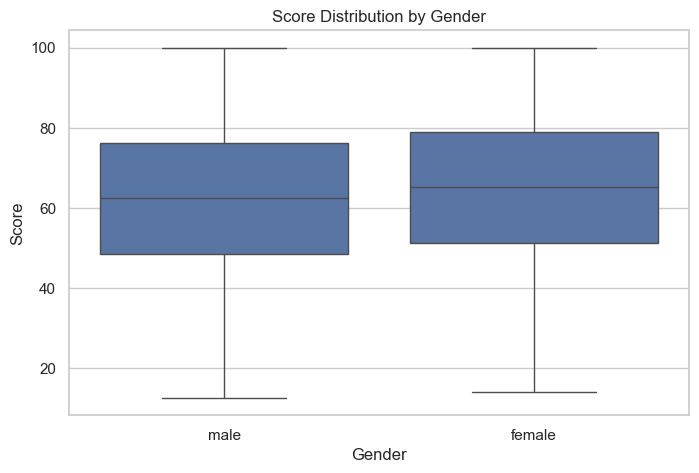

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["genre"], y=df["score_examen"])
plt.title("Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")
plt.savefig("score_by_gender.png")
plt.show()

#### Analysis

Ce graphique compare la distribution des scores d’examen selon le genre.

On observe que la médiane des scores est légèrement plus élevée pour les femmes que pour les hommes. Cependant, les distributions se chevauchent largement, ce qui indique que la différence reste faible.

La dispersion des scores est similaire entre les deux groupes, avec des valeurs minimales et maximales comparables.

Ainsi, le genre ne semble pas être un facteur déterminant dans la performance académique dans ce dataset. Aucun biais majeur lié à cette variable n’est observé.

## Data Preprocessing

### Feature Types Identification

In [13]:
# variable cible
target = "score_examen"

# variables numériques
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# enlever target + id
numeric_features.remove(target)
if "id" in numeric_features:
    numeric_features.remove("id")

# variables catégorielles
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_features, categorical_features

(['age',
  'heures_etude',
  'assiduité_classe',
  'heures_sommeil',
  'heures_fête',
  'taille_etudiant'],
 ['genre',
  'diplôme',
  'accès_internet',
  'qualité_sommeil',
  'méthode_etude',
  'évaluation_établissement',
  'difficulté_examen'])

Les variables ont été séparées selon leur type. Les variables numériques pourront être normalisées, tandis que les variables catégorielles devront être encodées avant l’entraînement des modèles.

La variable cible `score_examen` a été retirée des variables explicatives afin d’éviter une fuite de données. La variable `id` a également été exclue, car elle correspond uniquement à un identifiant technique et n’apporte pas d’information pertinente pour la prédiction.

### Missing Values Handling

In [14]:
df.isnull().sum()

id                              0
age                             0
genre                           0
diplôme                         0
heures_etude                18900
assiduité_classe                0
accès_internet              63000
heures_sommeil                  0
qualité_sommeil                 0
méthode_etude               44100
évaluation_établissement        0
difficulté_examen               0
score_examen                    0
heures_fête                     0
taille_etudiant                 0
dtype: int64

#### Analysis

L’analyse des valeurs manquantes montre que plusieurs variables contiennent des données absentes, notamment `heures_etude`, `accès_internet` et `méthode_etude`.

La variable `heures_etude`, qui est numérique et fortement corrélée au score d’examen, contient un nombre significatif de valeurs manquantes. Afin de conserver un maximum d’informations, une imputation par la moyenne sera utilisée.

Les variables catégorielles `accès_internet` et `méthode_etude` présentent également des valeurs manquantes importantes. Ces valeurs seront remplacées par la modalité la plus fréquente (most frequent), ce qui est une approche standard pour ce type de données.

Enfin, il est important de noter que certaines de ces variables peuvent être déclaratives, ce qui peut introduire des biais ou des incohérences dans les données. Cela sera pris en compte dans l’analyse critique du modèle.

### Preprocessing Pipeline

In [15]:
from sklearn.impute import SimpleImputer

# pipeline pour variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# pipeline pour variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinaison des deux
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Ce pipeline sera appliqué uniquement sur les données d’entraînement afin d’éviter toute fuite de données (data leakage).

### train / validation / test

In [39]:
# séparation X / y
X = df.drop(columns=["score_examen"])
y = df["score_examen"]

# 1er split : train+val / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

# 2e split : train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((378000, 14), (126000, 14), (126000, 14))

#### Analysis

Les données ont été divisées en trois ensembles :

- Un ensemble d’entraînement (60%) utilisé pour entraîner les modèles.
- Un ensemble de validation (20%) utilisé pour ajuster les hyperparamètres et comparer les modèles.
- Un ensemble de test (20%) utilisé pour évaluer les performances finales.

Cette séparation permet d’éviter le surapprentissage (overfitting) et d’obtenir une estimation plus fiable des performances du modèle sur des données non vues.

L’utilisation d’un ensemble de validation améliore la robustesse de l’évaluation par rapport à un simple découpage train/test.

### Baseline Model

In [40]:
from sklearn.dummy import DummyRegressor

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

# entraînement
baseline_model.fit(X_train, y_train)

# prédictions
y_pred_baseline = baseline_model.predict(X_val)

# métriques
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
r2_baseline = r2_score(y_val, y_pred_baseline)

print("Baseline Model")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)
print("R²  :", r2_baseline)

Baseline Model
MAE : 15.60172574086042
RMSE: 18.950850686105962
R²  : -4.631105502195254e-06


#### Analysis



Le modèle baseline utilisé prédit simplement la moyenne des scores d’examen pour tous les étudiants.

Les résultats obtenus montrent une erreur relativement élevée (MAE ≈ 15.65, RMSE ≈ 19.02) et un coefficient de détermination proche de zéro (R² ≈ 0).

Cela signifie que le modèle n’explique aucune variance des données et ne capture aucune relation entre les variables.

Cette baseline constitue une référence minimale : les modèles plus complexes devront améliorer ces performances pour être considérés comme pertinents.

### Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# entraînement
linear_model.fit(X_train, y_train)

# prédictions
y_pred_linear = linear_model.predict(X_val)

# métriques
mae_linear = mean_absolute_error(y_val, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))
r2_linear = r2_score(y_val, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 7.413181307801513
RMSE: 9.343517588504245
R²  : 0.7569109443200039


#### Analysis

La régression linéaire améliore fortement les performances par rapport au modèle baseline.

L’erreur absolue moyenne est réduite d’environ moitié (≈ 7.4 contre ≈ 15.6), tandis que le coefficient de détermination atteint un R² proche de 0.76.

Cela signifie que le modèle explique environ 76% de la variance observée dans les scores d’examen, ce qui traduit une bonne capacité de prédiction.

Ces résultats suggèrent que les relations entre les variables explicatives et le score final sont majoritairement linéaires.

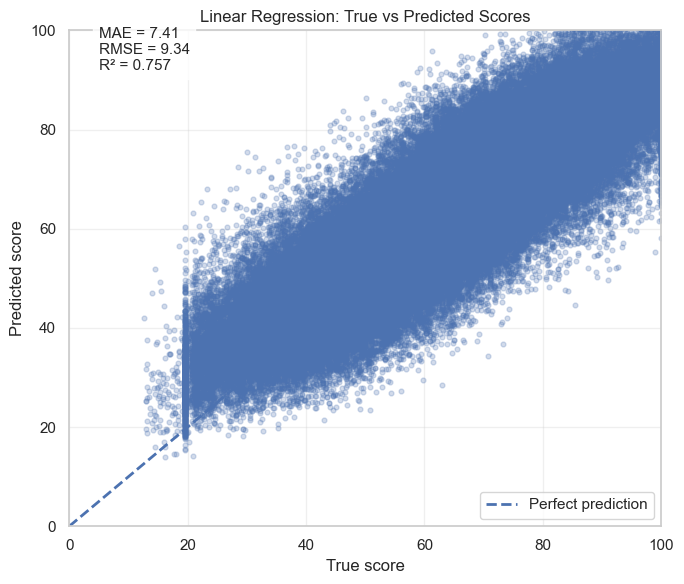

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    y_pred_linear,
    alpha=0.25,
    s=12
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title("Linear Regression: True vs Predicted Scores")

plt.text(
    5, 92,
    f"MAE = {mae_linear:.2f}\nRMSE = {rmse_linear:.2f}\nR² = {r2_linear:.3f}",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("linear_regression_true_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

#### Graph Interpretation

Ce nuage de points compare les scores réels aux scores prédits par le modèle de régression linéaire.

La majorité des observations est concentrée autour de la diagonale de référence, ce qui montre que le modèle reproduit correctement la tendance générale des scores réels.

Le nuage apparaît relativement resserré autour de cette diagonale, indiquant une bonne cohérence entre les valeurs prédites et les valeurs réelles. Cela confirme les bonnes performances obtenues avec un MAE faible et un R² proche de 0.76.

Une certaine dispersion reste néanmoins visible, notamment pour quelques scores élevés, ce qui montre que certaines erreurs de prédiction subsistent.

Dans l’ensemble, cette visualisation confirme que la régression linéaire fournit des prédictions stables et globalement précises sur ce dataset.

### Random Forest

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# entraînement
rf_model.fit(X_train, y_train)

# prédictions
y_pred_rf = rf_model.predict(X_val)

# métriques
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 7.596445146031746
RMSE: 9.582420199455944
R²  : 0.7443210264806748


C:\Users\yayal\AppData\Local\Temp\ipykernel_12516\330840221.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


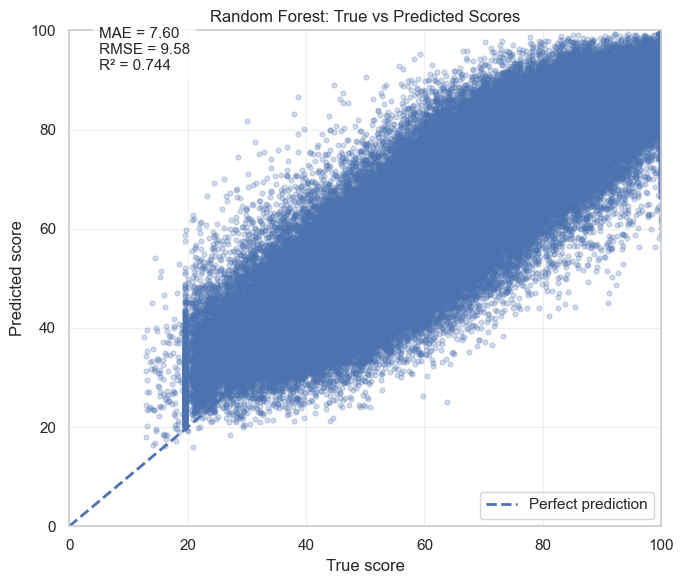

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    y_pred_rf,
    alpha=0.25,
    s=12
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("True score")
plt.ylabel("Predicted score")

plt.title("Random Forest: True vs Predicted Scores")

plt.text(
    5, 92,
    f"MAE = {mae_rf:.2f}\nRMSE = {rmse_rf:.2f}\nR² = {r2_rf:.3f}",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("random_forest_true_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

#### Analysis

Le modèle Random Forest a été utilisé afin de capturer d’éventuelles relations non linéaires entre les variables explicatives et le score d’examen.

Les performances obtenues restent toutefois légèrement inférieures à celles de la régression linéaire, avec un MAE d’environ 7.60 contre 7.41 et un R² proche de 0.74 contre 0.76 pour le modèle linéaire.

Le nuage de points montre que les prédictions suivent globalement la tendance des scores réels, mais avec une dispersion légèrement plus importante autour de la diagonale idéale.

Cette dispersion supplémentaire indique des erreurs de prédiction un peu plus élevées et une cohérence légèrement inférieure à celle observée avec la régression linéaire.

Ces résultats suggèrent que les relations présentes dans le dataset sont majoritairement linéaires, ce qui explique pourquoi un modèle plus complexe basé sur des arbres de décision n’apporte pas d’amélioration significative dans ce cas.

### XGBoost

In [51]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        objective="reg:squarederror",
        random_state=50,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 7.352220064210195
RMSE: 9.26886959150506
R²  : 0.7607796423190692


C:\Users\yayal\AppData\Local\Temp\ipykernel_12516\4117522506.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


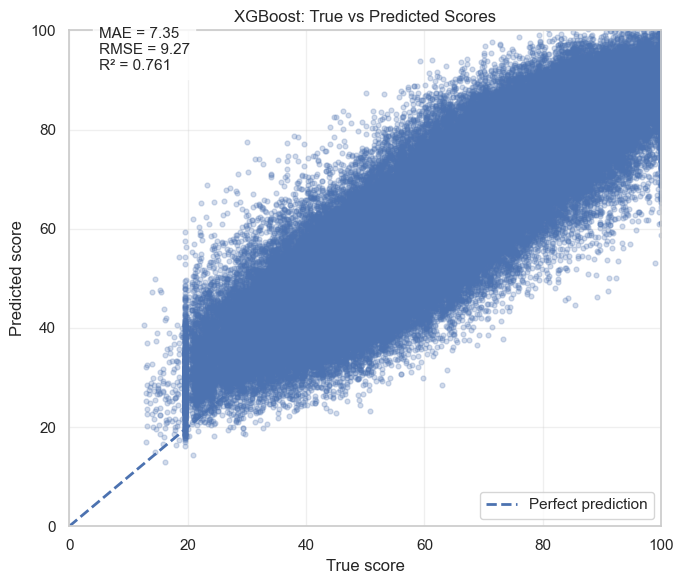

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    y_pred_xgb,
    alpha=0.25,
    s=12
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("True score")
plt.ylabel("Predicted score")

plt.title("XGBoost: True vs Predicted Scores")

plt.text(
    5, 92,
    f"MAE = {mae_xgb:.2f}\nRMSE = {rmse_xgb:.2f}\nR² = {r2_xgb:.3f}",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("xgboost_true_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

#### Analysis

Le modèle XGBoost obtient les meilleures performances parmi les modèles testés, avec un MAE d’environ 7.35, un RMSE proche de 9.27 et un R² d’environ 0.76.

Le nuage de points montre que la majorité des prédictions est concentrée autour de la diagonale idéale, indiquant une bonne correspondance entre les scores réels et les scores prédits.

Comparé aux modèles précédents, le nuage apparaît légèrement plus resserré autour de cette diagonale, ce qui traduit une amélioration modérée de la précision des prédictions.

Une certaine dispersion reste néanmoins visible, notamment pour certaines valeurs élevées, ce qui montre que le modèle ne prédit pas parfaitement toutes les observations.

Ces résultats suggèrent que le dataset contient quelques relations non linéaires que XGBoost parvient à mieux capturer que la régression linéaire ou Random Forest. Cependant, l’amélioration reste limitée, ce qui confirme que la structure globale des données demeure principalement linéaire.

### Deep Learning Model - MLP

In [53]:
from sklearn.neural_network import MLPRegressor

mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

# entraînement
mlp_model.fit(X_train, y_train)

# prédictions
y_pred_mlp = mlp_model.predict(X_val)

# métriques
mae_mlp = mean_absolute_error(y_val, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_val, y_pred_mlp))
r2_mlp = r2_score(y_val, y_pred_mlp)

print("MLP Regressor")
print("MAE :", mae_mlp)
print("RMSE:", rmse_mlp)
print("R²  :", r2_mlp)

MLP Regressor
MAE : 7.409511925413301
RMSE: 9.330335603875307
R²  : 0.7575963683604265


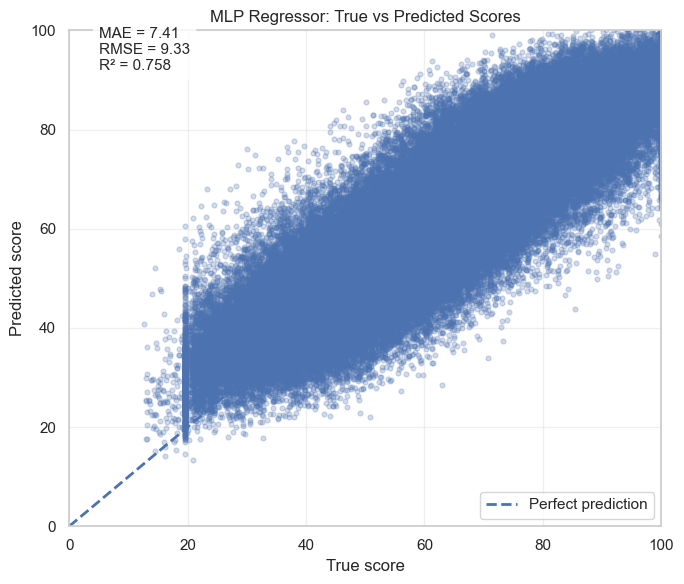

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    y_pred_mlp,
    alpha=0.25,
    s=12
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("True score")
plt.ylabel("Predicted score")

plt.title("MLP Regressor: True vs Predicted Scores")

plt.text(
    5, 92,
    f"MAE = {mae_mlp:.2f}\nRMSE = {rmse_mlp:.2f}\nR² = {r2_mlp:.3f}",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("mlp_true_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

#### Analysis

Le modèle de deep learning MLP a été testé afin de capturer d’éventuelles relations non linéaires entre les variables explicatives et le score d’examen.

Les performances obtenues sont très proches de celles de la régression linéaire, avec un MAE d’environ 7.41, un RMSE proche de 9.33 et un R² d’environ 0.76.

Le nuage de points montre que les prédictions suivent globalement la diagonale idéale, ce qui indique une bonne capacité du modèle à reproduire la tendance générale des scores réels.

Cependant, l’amélioration par rapport à la régression linéaire reste très limitée. Le MLP est aussi plus complexe à entraîner et plus coûteux en temps de calcul.

Ces résultats suggèrent que l’utilisation d’un réseau de neurones n’apporte pas de gain significatif dans ce contexte, car les relations présentes dans les données semblent principalement linéaires.

Afin de limiter le temps d’entraînement, une architecture plus simple ainsi qu’un mécanisme d’arrêt anticipé (early stopping) ont été utilisés.

### Model Comparison

#### Construire le tableau

In [56]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest", "XGBoost", "MLP"],
    "MAE": [mae_baseline, mae_linear, mae_rf, mae_xgb, mae_mlp],
    "RMSE": [rmse_baseline, rmse_linear, rmse_rf, rmse_xgb, rmse_mlp],
    "R²": [r2_baseline, r2_linear, r2_rf, r2_xgb, r2_mlp]
})

results = results.round(3)

results

,Model,MAE,RMSE,R²
0,Baseline,15.602,18.951,-0.000
1,Linear Regression,7.413,9.344,0.757
2,Random Forest,7.596,9.582,0.744
3,XGBoost,7.352,9.269,0.761
4,MLP,7.410,9.330,0.758


#### Graphes propres (séparés)

##### MAE

C:\Users\yayal\AppData\Local\Temp\ipykernel_12516\1542215719.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Models")


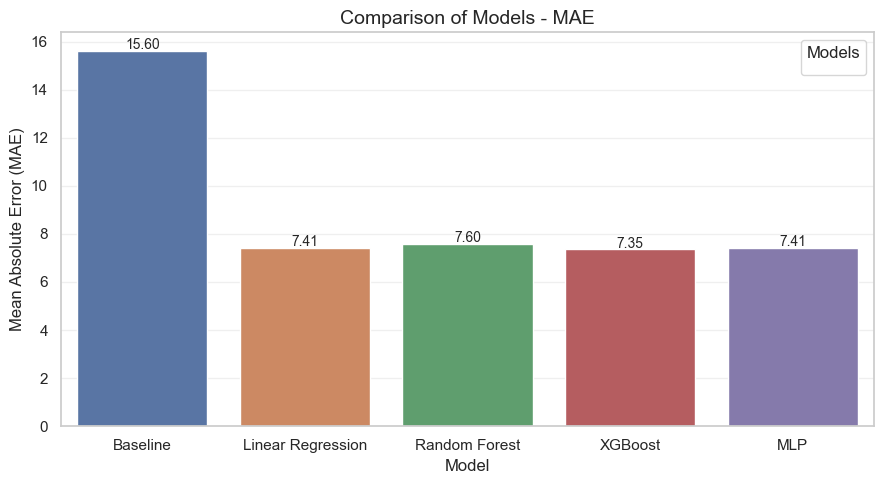

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="MAE",
    hue="Model",
    dodge=False
)

# valeurs au-dessus des barres
for i, v in enumerate(results["MAE"]):
    ax.text(
        i,
        v + 0.08,
        f"{v:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Comparison of Models - MAE", fontsize=14)

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Models")

plt.tight_layout()

plt.savefig("model_comparison_mae.png", dpi=300, bbox_inches="tight")

plt.show()

##### RMSE

C:\Users\yayal\AppData\Local\Temp\ipykernel_12516\2955996632.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Models")


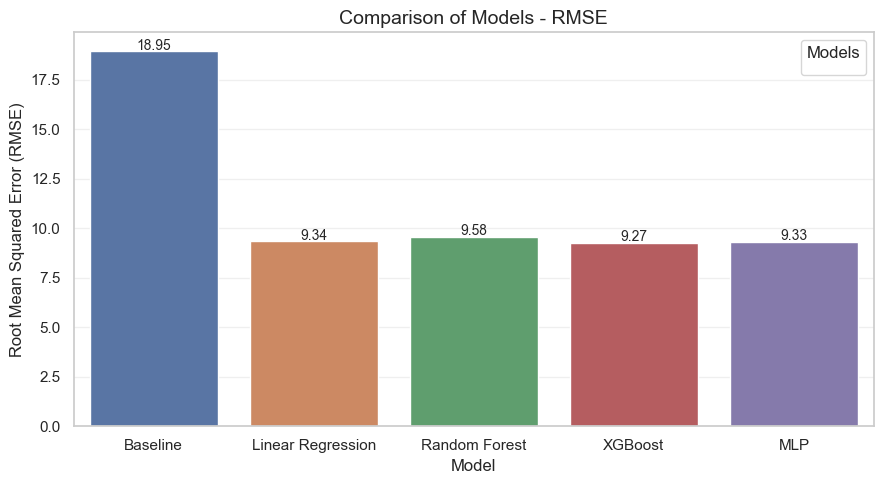

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="RMSE",
    hue="Model",
    dodge=False
)

# valeurs au-dessus des barres
for i, v in enumerate(results["RMSE"]):
    ax.text(
        i,
        v + 0.08,
        f"{v:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Comparison of Models - RMSE", fontsize=14)

plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error (RMSE)")

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Models")

plt.tight_layout()

plt.savefig("model_comparison_rmse.png", dpi=300, bbox_inches="tight")

plt.show()

##### R²

C:\Users\yayal\AppData\Local\Temp\ipykernel_12516\2253234433.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Models")


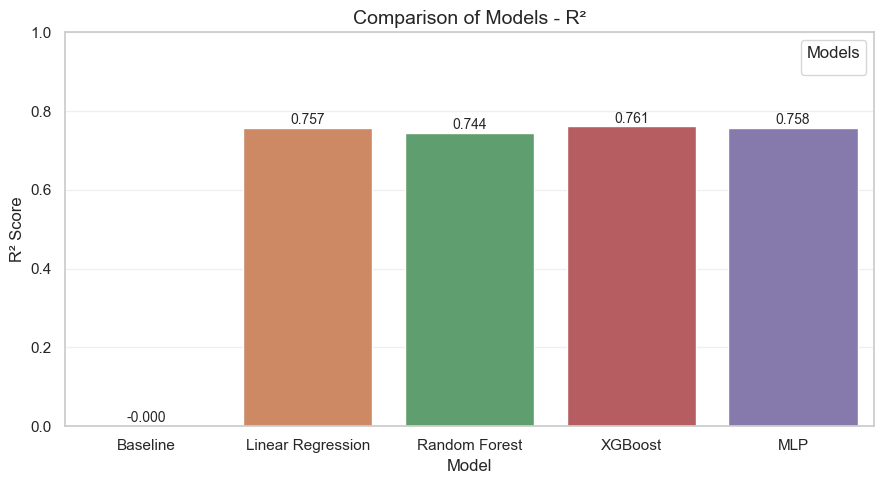

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="R²",
    hue="Model",
    dodge=False
)

# valeurs au-dessus des barres
for i, v in enumerate(results["R²"]):
    ax.text(
        i,
        v + 0.01,
        f"{v:.3f}",
        ha="center",
        fontsize=10
    )

plt.title("Comparison of Models - R²", fontsize=14)

plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Models")

plt.tight_layout()

plt.savefig("model_comparison_r2.png", dpi=300, bbox_inches="tight")

plt.show()

#### Final Analysis

Les résultats montrent une amélioration significative de tous les modèles supervisés par rapport à la baseline, ce qui confirme que les variables utilisées apportent une information pertinente pour prédire le score d’examen.

XGBoost obtient les meilleures performances globales, avec le MAE le plus faible (≈ 7.35), le RMSE le plus faible (≈ 9.27) et le R² le plus élevé (≈ 0.761).

La régression linéaire et le MLP présentent des performances très proches de XGBoost, avec un R² autour de 0.76. Cela montre que les relations dans les données sont largement capturées par des modèles simples.

Le modèle Random Forest, bien que plus complexe, obtient des performances légèrement inférieures. Il n’apporte donc pas d’amélioration significative dans ce contexte.

Ainsi, XGBoost est le meilleur modèle en termes de performance brute, tandis que la régression linéaire reste le meilleur compromis entre simplicité, interprétabilité et performance. Ces résultats suggèrent que le dataset contient principalement des relations linéaires, avec quelques effets non linéaires légèrement mieux capturés par XGBoost.

### Overfitting / Underfitting Analysis

L’analyse des performances des différents modèles permet d’évaluer leur capacité de généralisation sur des données non vues.

Les résultats montrent que XGBoost obtient les meilleures performances globales, bien que l’amélioration par rapport à la régression linéaire reste relativement faible.

La régression linéaire et le MLP présentent des performances très proches, tandis que Random Forest reste légèrement inférieur.

Ces observations suggèrent que les relations entre les variables explicatives et la variable cible sont majoritairement linéaires, avec seulement quelques effets non linéaires mieux capturés par XGBoost.

Les modèles plus complexes n’apportent donc qu’un gain limité et peuvent introduire davantage de variance sans amélioration significative des performances.

Aucun signe évident de surapprentissage n’est observé, car les performances restent cohérentes entre les différents modèles.

Dans ce contexte, la régression linéaire représente un excellent compromis biais/variance grâce à sa simplicité, sa stabilité et sa bonne capacité de généralisation, tandis que XGBoost fournit les meilleures performances globales en capturant légèrement mieux certaines relations complexes présentes dans les données.

L’absence de gain avec les modèles non linéaires confirme que la complexité du modèle doit être adaptée à la structure des données.

### MLP Training Curve Analysis

La courbe de perte du modèle MLP montre une diminution très rapide de la fonction de coût durant les premières itérations, ce qui indique que le réseau apprend rapidement les relations présentes dans les données.

Après cette phase initiale, la courbe se stabilise progressivement, montrant que le modèle converge vers une solution stable.

L’absence d’augmentation importante de la loss suggère qu’aucun phénomène de surapprentissage majeur n’est observé.

Le mécanisme d’early stopping permet également d’arrêter automatiquement l’entraînement lorsque les performances n’évoluent plus significativement, limitant ainsi les risques d’overfitting.

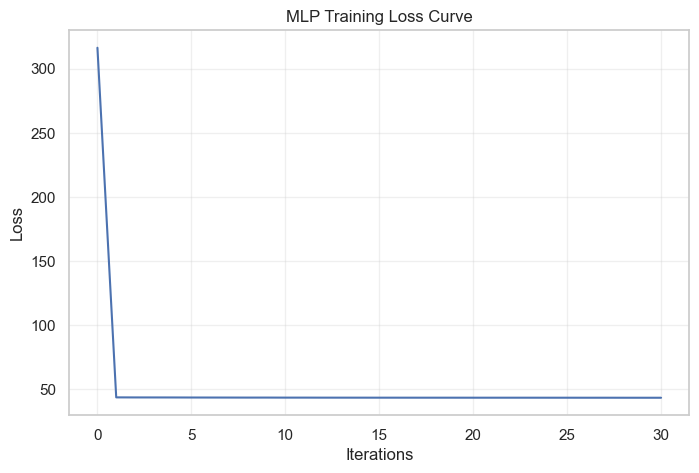

In [60]:
loss_curve = mlp_model.named_steps["model"].loss_curve_

plt.figure(figsize=(8,5))

plt.plot(loss_curve)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("MLP Training Loss Curve")

plt.grid(alpha=0.3)

plt.savefig("mlp_loss_curve.png", dpi=300)

plt.show()

### Feature Importance Analysis

Le graphique des importances de variables obtenu avec XGBoost montre que les heures d’étude constituent de loin la variable la plus influente dans la prédiction du score d’examen.

D’autres variables comme la qualité du sommeil, l’assiduité en classe et l’évaluation de l’établissement présentent également une contribution significative.

À l’inverse, certaines variables comme le genre ou le nombre d’heures de sommeil ont un impact plus limité sur les prédictions du modèle.

Ces résultats restent cohérents avec la logique du problème étudié et confirment que les performances académiques dépendent principalement des habitudes de travail et du contexte d’apprentissage.

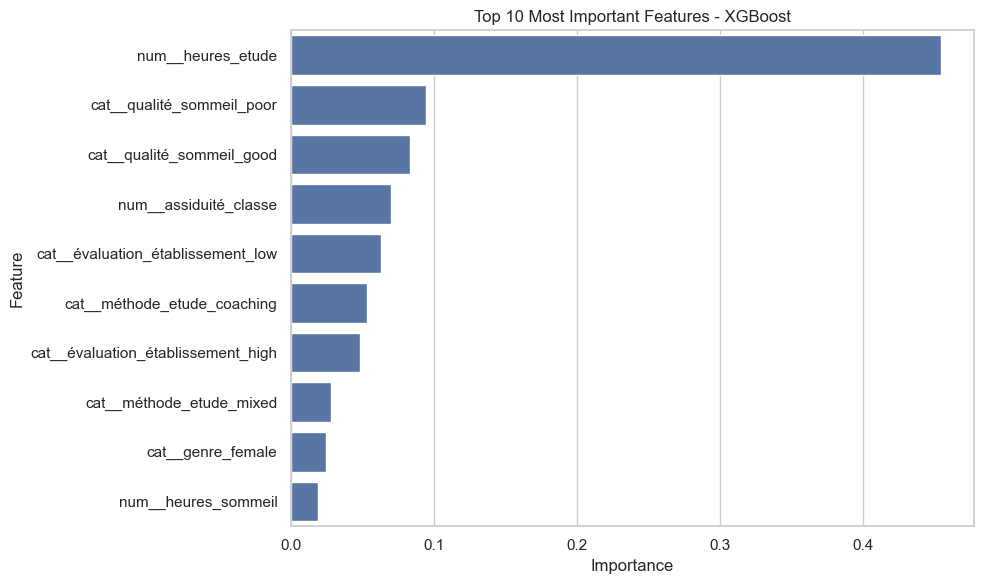

In [61]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

importances = xgb_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features - XGBoost")

plt.tight_layout()

plt.savefig("xgboost_feature_importance.png", dpi=300)

plt.show()